In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd

In [36]:
target = pd.read_parquet("target.parquet")
features = pd.read_parquet("weighted_features.parquet")

In [37]:
target.shape

(269609, 3)

In [38]:
features.shape

(269609, 117)

In [40]:
from sklearn.preprocessing import StandardScaler

features = features.copy()

numeric_cols = features.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["ID", "Year"]]

numeric_cols = [c for c in numeric_cols if c != 'Weight']

scaler = StandardScaler()
features[numeric_cols] = scaler.fit_transform(features[numeric_cols])

In [41]:
non_numeric_cols = features.select_dtypes(include=["object", "category"]).columns.tolist()
features = pd.get_dummies(features, columns=non_numeric_cols, drop_first=True)


In [43]:
features2 = features.sort_values(by=["ID", "Year"]).reset_index(drop=True)

features2.head()

,ID,Number_of_Rooms,House_Area,Car,Motorcycle,Bicycle,Radio,Cassette,Black_and_White_TV,Color_TV,...,Province_Qazvin,Province_Qom,Province_Razavi_Khorasan,Province_Semnan,Province_Sistan_and_Baluchestan,Province_South_Khorasan,Province_Tehran,Province_West_Azerbaijan,Province_Yazd,Province_Zanjan
0,10001000102,0.431263,1.961595,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,10001000105,0.431263,0.141641,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,10001000108,0.431263,0.921622,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,10001000108,0.431263,1.051618,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,10001000111,0.431263,1.103617,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [11]:
target2 = target.sort_values(by=["ID", "Year"]).reset_index(drop=True)

target2.head()

,ID,Year,Tenure
0,10001000102,1397,Owned_Estate_Land
1,10001000105,1397,Owned_Estate_Land
2,10001000108,1397,Owned_Estate_Land
3,10001000108,1398,Owned_Estate_Land
4,10001000111,1397,Owned_Estate_Land


In [44]:
non_numeric_cols = features2.select_dtypes(include=["object", "category"]).columns.tolist()

print(non_numeric_cols)

[]


In [45]:
features2.isna().sum().sort_values(ascending=False).head(20)


Elevator                    193775
Furniture_Expenditure        21369
Area_per_Capita               2989
Density                       2985
Income_Expenditure_Ratio      2982
Income                        2982
Divorced                      2980
Bachelor                      2980
Home_Expenditure              2980
Weight                        2980
Mean_Age                      2980
Max_Age                       2980
Min_Age                       2980
Literate_Count                2980
Student_Count                 2980
Net_Expenditure               2980
Married                       2980
Widowed                       2980
Unemployed                    2980
Income_without_Work           2980
dtype: int64

In [12]:
target2.isna().sum().sort_values(ascending=False).head(20)


Tenure    2989
ID           0
Year         0
dtype: int64

In [46]:
from sklearn.impute import SimpleImputer

# 1. حذف ستون Elevator
features2 = features2.drop(columns=["Elevator"])

# 2. پر کردن بقیه ستون‌های عددی با میانه
num_cols = features2.select_dtypes(include=["float64", "int64"]).columns
imputer = SimpleImputer(strategy="median")
features2[num_cols] = imputer.fit_transform(features2[num_cols])


In [47]:
features2.head()

,ID,Number_of_Rooms,House_Area,Car,Motorcycle,Bicycle,Radio,Cassette,Black_and_White_TV,Color_TV,...,Province_Qazvin,Province_Qom,Province_Razavi_Khorasan,Province_Semnan,Province_Sistan_and_Baluchestan,Province_South_Khorasan,Province_Tehran,Province_West_Azerbaijan,Province_Yazd,Province_Zanjan
0,10001000102,0.431263,1.961595,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,10001000105,0.431263,0.141641,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,10001000108,0.431263,0.921622,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,10001000108,0.431263,1.051618,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,10001000111,0.431263,1.103617,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [15]:
ids = features2[["ID", "Year"]]

In [16]:
ids.head()

,ID,Year
0,10001000102,1397.0
1,10001000105,1397.0
2,10001000108,1397.0
3,10001000108,1398.0
4,10001000111,1397.0


In [17]:
ids.shape

(269609, 2)

In [18]:
target2.head()

,ID,Year,Tenure
0,10001000102,1397,Owned_Estate_Land
1,10001000105,1397,Owned_Estate_Land
2,10001000108,1397,Owned_Estate_Land
3,10001000108,1398,Owned_Estate_Land
4,10001000111,1397,Owned_Estate_Land


In [19]:

target3 = target2[target2["Tenure"].notna()]

In [48]:
features3 = features2.loc[target3.index]

In [21]:
target3.shape

(266620, 3)

In [49]:
features3.shape

(266620, 145)

In [50]:
non_numeric_cols = features3.select_dtypes(include=["object", "category"]).columns.tolist()

print(non_numeric_cols)

[]


In [24]:
print(features3.dtypes)
print(target3.dtypes)


ID                           UInt64
Number_of_Rooms             float64
House_Area                  float64
Car                         boolean
Motorcycle                  boolean
                             ...   
Province_South_Khorasan        bool
Province_Tehran                bool
Province_West_Azerbaijan       bool
Province_Yazd                  bool
Province_Zanjan                bool
Length: 145, dtype: object
ID          UInt64
Year         int64
Tenure    category
dtype: object


In [25]:
target3 = target3.copy()
target3['Tenure'] = target3['Tenure'].cat.codes

In [64]:
categories = target2['Tenure'].cat.categories
print(categories)


Index(['Owned_Estate_Land', 'Owned_Estate', 'Rent', 'Mortgage', 'Service',
       'Free', 'Other'],
      dtype='object')


In [26]:
target3.shape

(266620, 3)

In [27]:
target3.head()

,ID,Year,Tenure
0,10001000102,1397,0
1,10001000105,1397,0
2,10001000108,1397,0
3,10001000108,1398,0
4,10001000111,1397,0


In [28]:
target3 = target3["Tenure"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    features3, target3, test_size=0.2, random_state=42, stratify=target3
)

In [53]:
model_reg = LogisticRegression(max_iter=1000)
model_reg.fit(X_train, y_train, sample_weight=X_train['Weight'])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [54]:
y_pred = model_reg.predict(X_test)

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7812242142374916

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88     41658
           1       0.00      0.00      0.00       287
           2       0.00      0.00      0.00      4988
           3       0.00      0.00      0.00      1889
           4       0.00      0.00      0.00       484
           5       0.00      0.00      0.00      3946
           6       0.00      0.00      0.00        72

    accuracy                           0.78     53324
   macro avg       0.11      0.14      0.13     53324
weighted avg       0.61      0.78      0.69     53324


Confusion Matrix:
 [[41658     0     0     0     0     0     0]
 [  287     0     0     0     0     0     0]
 [ 4988     0     0     0     0     0     0]
 [ 1889     0     0     0     0     0     0]
 [  484     0     0     0     0     0     0]
 [ 3946     0     0     0     0     0     0]
 [   72     0     0     0     0     0     0]]


D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [58]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

y_train2 = y_train.reset_index(drop=True).astype(int)
X_train2 = X_train.astype(float)


# فرض کنیم X_train و y_train رو داریم
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train2, y_train2)

# مدل رو آموزش میدیم
model_reg_smote = LogisticRegression(max_iter=1000)
model_reg_smote.fit(X_train_res, y_train_res, sample_weight=X_train_res['Weight'])

# پیش‌بینی
y_pred2 = model_reg_smote.predict(X_test)

# گزارش عملکرد
print("Classification Report:")
print(classification_report(y_test, y_pred2))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred2))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     41658
           1       0.00      0.00      0.00       287
           2       0.00      0.00      0.00      4988
           3       0.04      1.00      0.07      1889
           4       0.00      0.00      0.00       484
           5       0.00      0.00      0.00      3946
           6       0.00      0.00      0.00        72

    accuracy                           0.04     53324
   macro avg       0.01      0.14      0.01     53324
weighted avg       0.00      0.04      0.00     53324

Confusion Matrix:
[[    0     0     0 41658     0     0     0]
 [    0     0     0   287     0     0     0]
 [    0     0     0  4988     0     0     0]
 [    0     0     0  1889     0     0     0]
 [    0     0     0   484     0     0     0]
 [    0     0     0  3946     0     0     0]
 [    0     0     0    72     0     0     0]]


D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [29]:
y_train = y_train.reset_index(drop=True).astype(int)


In [30]:
X_train = X_train.astype(float)


In [31]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [32]:
# مدل رو آموزش میدیم
model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

# پیش‌بینی
y_pred = model.predict(X_test)

# گزارش عملکرد
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     41658
           1       0.00      0.00      0.00       287
           2       0.00      0.00      0.00      4988
           3       0.00      0.00      0.00      1889
           4       0.00      0.00      0.00       484
           5       0.00      0.00      0.00      3946
           6       0.00      1.00      0.00        72

    accuracy                           0.00     53324
   macro avg       0.00      0.14      0.00     53324
weighted avg       0.00      0.00      0.00     53324

Confusion Matrix:
[[    0     0     0     0     0     0 41658]
 [    0     0     0     0     0     0   287]
 [    0     0     0     0     0     0  4988]
 [    0     0     0     0     0     0  1889]
 [    0     0     0     0     0     0   484]
 [    0     0     0     0     0     0  3946]
 [    0     0     0     0     0     0    72]]


D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\SUT\cources\regression\project2\project2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [66]:
model_forest = RandomForestClassifier(random_state=42)
model_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:

y_pred = model_forest.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8101980346560648

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.99      0.90     41658
           1       1.00      0.04      0.08       287
           2       0.56      0.24      0.33      4988
           3       0.61      0.09      0.15      1889
           4       0.94      0.10      0.17       484
           5       0.72      0.16      0.26      3946
           6       1.00      0.08      0.15        72

    accuracy                           0.81     53324
   macro avg       0.81      0.24      0.29     53324
weighted avg       0.79      0.81      0.76     53324


Confusion Matrix:
 [[41161     0   342    28     0   127     0]
 [  262    12    11     0     0     2     0]
 [ 3667     0  1174    62     0    85     0]
 [ 1448     0   263   166     0    12     0]
 [  406     0    23     1    46     8     0]
 [ 2989     0   299    17     3   638     0]
 [   57     0     1     0     0     8     6]]


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# تعریف مدل پایه
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# شبکه جستجو برای هایپرپارامترها
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

# تنظیم GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_macro",   # برای داده نامتوازن بهتر از accuracy هست
    cv=3,                 # 3-fold cross-validation
    verbose=2,
    n_jobs=-1
)

# آموزش
grid_search.fit(X_train, y_train)

# بهترین پارامترها
print("Best Parameters:", grid_search.best_params_)
print("Best F1_macro Score:", grid_search.best_score_)

# مدل نهایی
best_rf = grid_search.best_estimator_

# ارزیابی روی test
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Fitting 3 folds for each of 162 candidates, totalling 486 fits


OSError: [WinError 1450] Insufficient system resources exist to complete the requested service

In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# مدل XGBoost
xgb = XGBClassifier(
    n_estimators=500,       # تعداد درخت
    learning_rate=0.1,      # نرخ یادگیری
    max_depth=6,            # عمق درخت‌ها
    subsample=0.8,          # نمونه‌گیری ردیف‌ها
    colsample_bytree=0.8,   # نمونه‌گیری فیچرها
    eval_metric="mlogloss", # برای classification چندکلاسه
    tree_method="hist",     # سریع‌تر و حافظه کمتر
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
)

# آموزش با early stopping
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)


[0]	validation_0-mlogloss:1.73119
[1]	validation_0-mlogloss:1.57314
[2]	validation_0-mlogloss:1.44839
[3]	validation_0-mlogloss:1.34626
[4]	validation_0-mlogloss:1.26074
[5]	validation_0-mlogloss:1.18809
[6]	validation_0-mlogloss:1.12518
[7]	validation_0-mlogloss:1.07013
[8]	validation_0-mlogloss:1.02212
[9]	validation_0-mlogloss:0.97991
[10]	validation_0-mlogloss:0.94265
[11]	validation_0-mlogloss:0.90940
[12]	validation_0-mlogloss:0.87981
[13]	validation_0-mlogloss:0.85339
[14]	validation_0-mlogloss:0.82975
[15]	validation_0-mlogloss:0.80845
[16]	validation_0-mlogloss:0.78908
[17]	validation_0-mlogloss:0.77199
[18]	validation_0-mlogloss:0.75676
[19]	validation_0-mlogloss:0.74271
[20]	validation_0-mlogloss:0.72985
[21]	validation_0-mlogloss:0.71815
[22]	validation_0-mlogloss:0.70761
[23]	validation_0-mlogloss:0.69808
[24]	validation_0-mlogloss:0.68943
[25]	validation_0-mlogloss:0.68137
[26]	validation_0-mlogloss:0.67423
[27]	validation_0-mlogloss:0.66734
[28]	validation_0-mlogloss:0.6

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'mlogloss'


In [37]:



# پیش‌بینی
y_pred = xgb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     41658
           1       0.59      0.23      0.33       287
           2       0.55      0.34      0.42      4988
           3       0.49      0.23      0.31      1889
           4       0.75      0.30      0.43       484
           5       0.58      0.19      0.28      3946
           6       0.87      0.28      0.42        72

    accuracy                           0.82     53324
   macro avg       0.67      0.36      0.44     53324
weighted avg       0.79      0.82      0.79     53324


Confusion Matrix:
[[40504    15   646   185    18   287     3]
 [  189    65    24     5     0     4     0]
 [ 2885    16  1710   196    11   170     0]
 [ 1052     8   343   435     5    46     0]
 [  270     1    38    15   146    14     0]
 [ 2769     6   368    49    14   740     0]
 [   45     0     1     0     1     5    20]]


In [38]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import numpy as np

# محاسبه وزن کلاس‌ها
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# آماده کردن وزن نمونه‌ها
sample_weights = np.array([class_weights[label] for label in y_train])

# مدل XGBoost
xgb_weight = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax',  # یا 'multi:softprob' اگر بخواهی probabilities
    n_jobs=-1,
    eval_metric='mlogloss',  # مناسب چندکلاسه
    early_stopping_rounds=20
)

# آموزش مدل با early stopping
xgb_weight.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=True
)

# پیش‌بینی
y_pred = xgb_weight.predict(X_test)

# گزارش دقت
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


[0]	validation_0-mlogloss:1.88863
[1]	validation_0-mlogloss:1.83844
[2]	validation_0-mlogloss:1.79447
[3]	validation_0-mlogloss:1.75498
[4]	validation_0-mlogloss:1.71896
[5]	validation_0-mlogloss:1.68720
[6]	validation_0-mlogloss:1.65812
[7]	validation_0-mlogloss:1.63189
[8]	validation_0-mlogloss:1.60859
[9]	validation_0-mlogloss:1.58619
[10]	validation_0-mlogloss:1.56727
[11]	validation_0-mlogloss:1.54835
[12]	validation_0-mlogloss:1.53053
[13]	validation_0-mlogloss:1.51480
[14]	validation_0-mlogloss:1.49950
[15]	validation_0-mlogloss:1.48571
[16]	validation_0-mlogloss:1.47322
[17]	validation_0-mlogloss:1.46085
[18]	validation_0-mlogloss:1.44989
[19]	validation_0-mlogloss:1.43866
[20]	validation_0-mlogloss:1.42802
[21]	validation_0-mlogloss:1.41862
[22]	validation_0-mlogloss:1.40928
[23]	validation_0-mlogloss:1.40076
[24]	validation_0-mlogloss:1.39296
[25]	validation_0-mlogloss:1.38456
[26]	validation_0-mlogloss:1.37619
[27]	validation_0-mlogloss:1.36894
[28]	validation_0-mlogloss:1.3

In [ ]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

y_train = y_train.astype(int)
X_train = X_train.astype(float)

# ---------- SMOTE ----------
smote = SMOTE(random_state=42, sampling_strategy="auto")
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))
print("After SMOTE:", dict(pd.Series(y_train_res).value_counts()))

# ---------- XGBoost ----------
xgb_smote = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_smote.fit(X_train_res, y_train_res)

# ---------- Evaluation ----------
y_pred = xgb_smote.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Before SMOTE: {0: np.int64(166633), 2: np.int64(19954), 5: np.int64(15784), 3: np.int64(7554), 4: np.int64(1937), 1: np.int64(1148), 6: np.int64(286)}
After SMOTE: {0: np.int64(166633), 2: np.int64(166633), 5: np.int64(166633), 1: np.int64(166633), 3: np.int64(166633), 4: np.int64(166633), 6: np.int64(166633)}


In [72]:
from xgboost import XGBClassifier


xgb2 = XGBClassifier(
    objective="multi:softprob",  # خروجی: احتمال هر کلاس
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb2.fit(X_train, y_train, sample_weight=X_train['Weight'])

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [74]:
import numpy as np

y_proba = xgb2.predict_proba(X_test)

# مثلاً برای کلاس 1 آستانه رو پایین‌تر می‌گیریم (0.2 به جای 0.5)
y_pred = []
for row in y_proba:
    if row[1] > 0.2:   # حساسیت بیشتر روی کلاس 1
        y_pred.append(1)
    else:
        y_pred.append(np.argmax(row))

In [75]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     41658
           1       0.45      0.34      0.39       287
           2       0.54      0.34      0.42      4988
           3       0.49      0.21      0.30      1889
           4       0.70      0.29      0.41       484
           5       0.57      0.18      0.28      3946
           6       0.78      0.25      0.38        72

    accuracy                           0.82     53324
   macro avg       0.63      0.37      0.44     53324
weighted avg       0.78      0.82      0.78     53324


Confusion Matrix:
[[40404    64   669   184    21   311     5]
 [  163    97    22     2     0     3     0]
 [ 2873    28  1714   190    17   166     0]
 [ 1058     7   368   406     5    45     0]
 [  294     1    30     8   138    13     0]
 [ 2787    17   367    46    13   716     0]
 [   46     0     2     0     2     4    18]]


In [42]:
xgb2.feature_importances_

array([0.00788269, 0.00697441, 0.01019628, 0.01085269, 0.00684143,
       0.00326031, 0.00396454, 0.00419491, 0.00302564, 0.00296181,
       0.00365321, 0.00377197, 0.00268487, 0.00437546, 0.00360132,
       0.00347268, 0.00329784, 0.00441465, 0.00424954, 0.00405214,
       0.00480486, 0.00543201, 0.00436485, 0.00417328, 0.00365658,
       0.0064765 , 0.00304728, 0.00881188, 0.02474164, 0.00438207,
       0.00347693, 0.00348269, 0.00445778, 0.00279913, 0.0038406 ,
       0.00661985, 0.01085724, 0.01263951, 0.00607926, 0.00691448,
       0.01050299, 0.00523633, 0.00473116, 0.00714115, 0.00327762,
       0.00526797, 0.00541336, 0.00790984, 0.0058111 , 0.00177988,
       0.00251399, 0.00100902, 0.00232087, 0.00432182, 0.        ,
       0.        , 0.0133966 , 0.00220631, 0.00454063, 0.00375873,
       0.00374205, 0.00364718, 0.0053416 , 0.        , 0.00939266,
       0.00463028, 0.00223029, 0.00358093, 0.01476525, 0.00697489,
       0.00285905, 0.00169889, 0.00168301, 0.0043613 , 0.01022

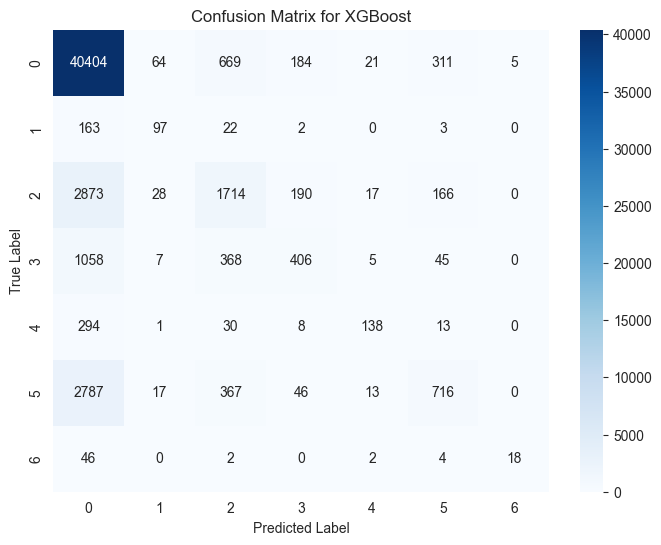

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for XGBoost")
plt.show()

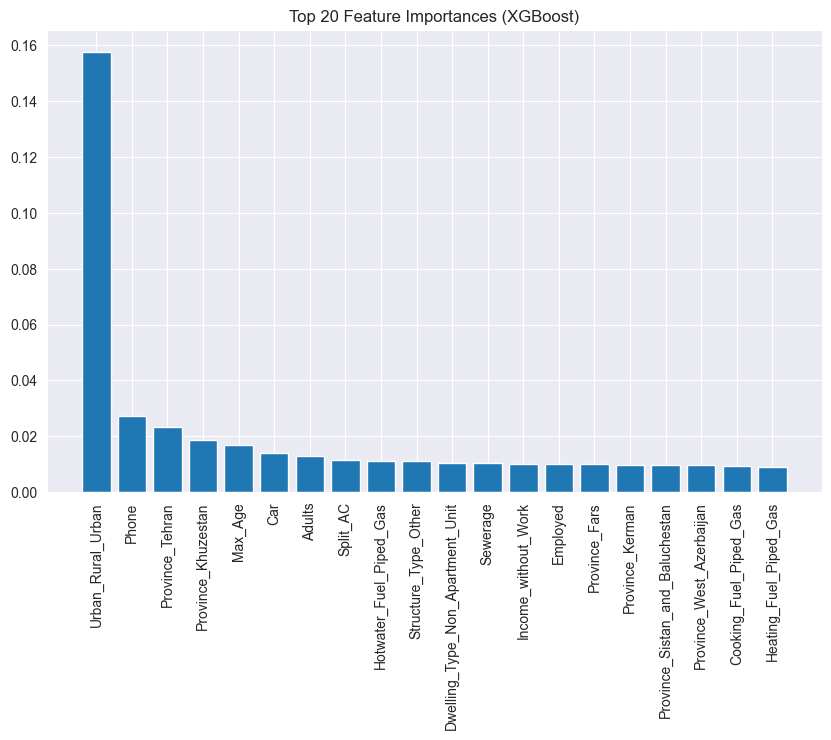

In [77]:
importances = xgb2.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), [X_train.columns[i] for i in indices[:20]], rotation=90)
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()


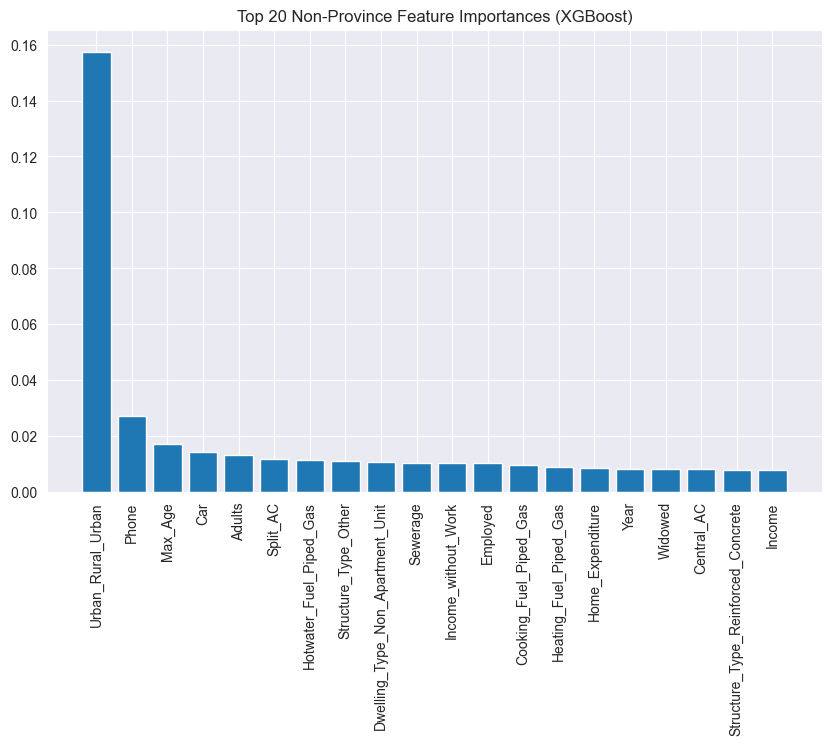

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature importances
importances = xgb2.feature_importances_
feature_names = X_train.columns

# Filter only non-province features
mask = ~feature_names.str.startswith("Province_")
non_province_importances = importances[mask]
non_province_features = feature_names[mask]

# Sort descending
indices = np.argsort(non_province_importances)[::-1]

# Plot top 20 non-province features
plt.figure(figsize=(10,6))
plt.bar(range(20), non_province_importances[indices[:20]], align="center")
plt.xticks(range(20), [non_province_features[i] for i in indices[:20]], rotation=90)
plt.title("Top 20 Non-Province Feature Importances (XGBoost)")
plt.show()
